In [1]:
import sys
import os

sys.path.append(os.path.abspath('../'))

In [2]:
import networkx as nx
import pandas as pd
import math

from Classes.BiasedInfluenceGraph import *
from Classes.WordGenerator import *

# Consensus Experiments

In [3]:
# -------------- Define dictionaries to store unique values for each pair of nodes -------------
# Unique sigma value for each pair
sigma_values = {}

# Unique back value for each pair
back_values = {}

# Unique influence value for each pair
influence_values = {}

# Assigned bias (only used if different bias functions are used for each pair)
bias_fn = {}

def get_unique_random_sigma_for_pair(e):
    if e not in sigma_values:
        sigma_values[e] = random.uniform(0.001, 4)
    return sigma_values[e]

def get_unique_random_sigma_R(e):
    if e not in sigma_values:
        sigma_values[e] = random.uniform(0.001, 0.999)
    return sigma_values[e]

def get_unique_random_sigma_M(e):
    if e not in sigma_values:
        sigma_values[e] = random.uniform(1, 4)
    return sigma_values[e]

def get_unique_random_back_for_pair(e):
    if e not in back_values:
        back_values[e] = -1 * random.uniform(1, 2)
    return back_values[e]

def get_unique_random_influence_for_pair(e):
    if e not in influence_values:
        influence_values[e] = random.uniform(0, 1)
    return influence_values[e]

def get_unique_random_influence_consensus_for_pair(e):
    if e not in influence_values:
        try:
            s = sigma_values[e]
            influence_values[e] = random.uniform(0, 1 / s) if s >= 1 else random.uniform(0, 1)
        except KeyError:
            influence_values[e] = random.uniform(0, 1)
    return influence_values[e]

# ------------------------- Definition of bias functions -------------------------
clamp = lambda x: max(-1, min(1, x))


#  ----------------- I region -----------------
def ins(G,e):
    return 0

#  ----------------- R region -----------------
def conf(G, e):
    delta = 0.01
    x = G.opinion[e[0]] - G.opinion[e[1]]
    return clamp(x*(1 + delta - abs(x))/(1+delta))

def linR(G, e):
    sigma = get_unique_random_sigma_R(e)
    x = G.opinion[e[0]] - G.opinion[e[1]]
    return clamp(sigma * x)

def wave(G,e):
    x = G.opinion[e[0]] - G.opinion[e[1]]
    if x >= -1 and x < -0.02:
        return clamp((math.sin(25*x )*x + x)/2 * 0.9 - 0.01)
    elif x >= -0.02 and x <= 0.02:
        return clamp(x*0.734259)
    elif x <= 1 and x > 0.02:
        return clamp((math.sin(25*x + math.pi)*x + x)/2 * 0.9 + 0.01)
  
#  ----------------- M region -----------------
def fan(G,e):
    x = G.opinion[e[0]] - G.opinion[e[1]]
    return 0 if x == 0 else clamp(x/abs(x))

def linM(G, e):
    sigma = get_unique_random_sigma_M(e)
    x = G.opinion[e[0]] - G.opinion[e[1]]
    return clamp(sigma * x)

# #  ----------------- R and M region -----------------

# if sigma between 0 and 1, lin is in R, else if sigma > 1, lin is in M
def lin(G, e):
    sigma = get_unique_random_sigma_for_pair(e)
    x = G.opinion[e[0]] - G.opinion[e[1]]
    return clamp(sigma * x)

#  ----------------- Bf region -----------------
def neg_lin(G, e):
    back = get_unique_random_back_for_pair(e)
    x = G.opinion[e[0]] - G.opinion[e[1]]
    return clamp(back * x)

def backf(G,e):
    x = G.opinion[e[0]] - G.opinion[e[1]]
    return clamp(-(x ** 3))


# #  ----------- Random bias selection ------------
def random_R(G,e):
    x = G.opinion[e[0]] - G.opinion[e[1]]
    if e not in bias_fn:
        bias_fn[e] = random.choices([linR,conf,wave])[0]
    
    return bias_fn[e](G,e)

def random_M(G,e):
    x = G.opinion[e[0]] - G.opinion[e[1]]
    if e not in bias_fn:
        bias_fn[e] = random.choices([linM,fan])[0]
    
    return bias_fn[e](G,e)

def random_B(G,e):
    x = G.opinion[e[0]] - G.opinion[e[1]]
    if e not in bias_fn:
        bias_fn[e] = random.choices([neg_lin, backf])[0]
    
    return bias_fn[e](G,e)

def random_lin_ins(G,e):
    x = G.opinion[e[0]] - G.opinion[e[1]]
    if e not in bias_fn:
        bias_fn[e] = random.choices([lin, ins])[0]
    
    return bias_fn[e](G,e)

def random_bias_fun(G,e):
    if e not in bias_fn:
        bias_fn[e] = random.choices([ins, lin, conf, fan, neg_lin, backf])[0]
    return bias_fn[e](G,e)

# ------------------------- Definition of influence functions -------------------------

def random_inf(G, e):
    return get_unique_random_influence_for_pair(e)

def random_inf_consensus(G, e):
    return get_unique_random_influence_consensus_for_pair(e)

In [4]:
df_experiment = pd.DataFrame(columns=['size', 'graph_id', 'word', 'consensus'])
df_graphs = pd.DataFrame(columns=['size', 'graph_id', 'init_state', 'biases', 'influences', 'factors' ])

def add_df_entry(size, graph_id, word, consensus):
    global df_experiment
    row = {'size': size,
        'graph_id': graph_id,
        'word': word,
        'consensus': consensus}

    df_experiment.loc[len(df_experiment)] = row

def add_df_graph(size, graph_id, state, biases, influences, factors,):
    global df_graphs
    row = {'size': size,
        'graph_id': graph_id,
        'init_state': state,
        'biases': biases,
        'influences': influences,
        'factors': factors}

    df_graphs.loc[len(df_graphs)] = row

In [ ]:
graph_sizes = [4, 8, 16, 32, 64, 128, 256, 512]

# Number of runs per graph
r = 100

#Number of graphs per size
n = 30

# Probability of edge creation
p = 0.4

for size in graph_sizes:
    print("-------------------------------------------------------------")
    print(f"-                  NEW SIZE   {size}                       -")
    print("-------------------------------------------------------------")
    
    for i in range(n):
        
        print(f"-------------------- New Graph {i+1} --------------------")

        influence_values = {}
        sigma_values = {}
        back_values = {}
        bias_fn = {}

        strongly_connected = False
        while not strongly_connected:
            G = BiasedInfluenceGraph(size,G=nx.fast_gnp_random_graph(size, p, directed=True), influence_fn=random_inf, bias_fn=random_B)
            strongly_connected = nx.is_strongly_connected(G)
        

        for j in range(r):
            word_len = 100*size
            w = generate_random_word(G, word_len)
            G.execute_word(w)

            consensus = G.consensus()

            #print(f"Size: {size}, Graph: {i+1}, Run: {j+1}, Consensus: {consensus}")

            G.reset_opinions()

            add_df_entry(size, i+1, w, consensus)

        add_df_graph(size,i+1, G.initial_state, bias_fn, influence_values.copy(), [sigma_values.copy(), back_values.copy()])

-------------------------------------------------------------
-                  NEW SIZE   4                       -
-------------------------------------------------------------
-------------------- New Graph 1 --------------------
-------------------- New Graph 2 --------------------
-------------------- New Graph 3 --------------------
-------------------- New Graph 4 --------------------
-------------------- New Graph 5 --------------------
-------------------- New Graph 6 --------------------
-------------------- New Graph 7 --------------------
-------------------- New Graph 8 --------------------
-------------------- New Graph 9 --------------------
-------------------- New Graph 10 --------------------
-------------------- New Graph 11 --------------------
-------------------- New Graph 12 --------------------
-------------------- New Graph 13 --------------------
-------------------- New Graph 14 --------------------
-------------------- New Graph 15 --------------------
----

In [ ]:
df_experiment.info()
df_graphs.info()

<class 'pandas.DataFrame'>
Index: 24000 entries, 0 to 23999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   size       24000 non-null  int64 
 1   graph_id   24000 non-null  int64 
 2   word       24000 non-null  object
 3   consensus  24000 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 773.4+ KB
<class 'pandas.DataFrame'>
Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   size        240 non-null    int64 
 1   graph_id    240 non-null    int64 
 2   init_state  240 non-null    object
 3   biases      240 non-null    object
 4   influences  240 non-null    object
 5   factors     240 non-null    object
dtypes: int64(2), object(4)
memory usage: 13.1+ KB


In [ ]:
df_experiment.to_csv('./dataframes/Backfire.csv', index=False)
df_graphs.to_csv('./dataframes/Backfire_graphs.csv', index=False)

In [ ]:
df_graphs.head()

In [ ]:
df_experiment[df_experiment['consensus'] == False]

In [ ]:
df_graphs[df_graphs['size'] == 32]

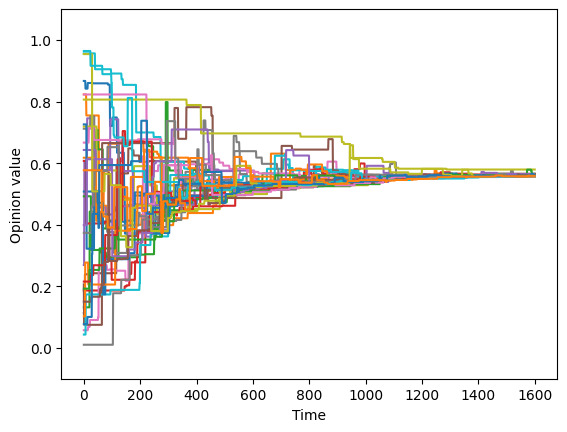

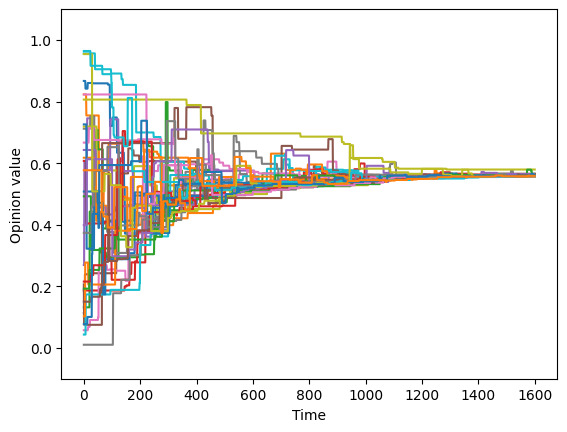

In [58]:
g_id = 105
w_id = 10599

op = list(df_graphs.loc[g_id].init_state.values())
n = 32

influence_values = df_graphs.loc[g_id].influences
sigma_values = df_graphs.loc[g_id].factors[0]

aux_graph = nx.DiGraph()
aux_graph.add_nodes_from([i for i in range(n)])
aux_graph.add_edges_from(df_graphs.loc[g_id].influences.keys())

G = BiasedInfluenceGraph(n, ops=op,G=aux_graph, influence_fn=random_inf_consensus, bias_fn=lin )
w = df_experiment.loc[w_id].word

G.execute_word(w)

G.plot_opinion_evolution()

In [59]:
print(nx.is_strongly_connected(G))
print(G.consensus())

True
False


In [52]:
influence_values

{(44, 2): 0.1517639876559569,
 (46, 18): 0.22291721519156882,
 (58, 38): 0.04113457550871482,
 (59, 19): 0.7403761556572894,
 (17, 36): 0.17368171367895505,
 (36, 34): 0.0027124887386279087,
 (8, 2): 0.7439069114511379,
 (43, 37): 0.2193861628230227,
 (30, 34): 0.5354183324161644,
 (49, 61): 0.537988536896763,
 (1, 51): 0.05771718384047536,
 (4, 40): 0.5178765358696947,
 (36, 23): 0.0752495495548854,
 (44, 7): 0.02208196246195071,
 (61, 35): 0.10740049525249734,
 (48, 46): 0.20160709974652097,
 (59, 45): 0.1435966210395529,
 (38, 57): 0.7979364674105278,
 (31, 24): 0.2601359541206293,
 (31, 7): 0.7429831476755323,
 (36, 21): 0.2515361045992123,
 (5, 10): 0.32743973027086676,
 (42, 11): 0.31985877610664926,
 (43, 59): 0.012581437485153899,
 (4, 44): 0.7269936496057586,
 (23, 36): 0.34482650692630845,
 (63, 14): 0.06372754927466183,
 (10, 53): 0.16266958934856998,
 (17, 22): 0.10627131154757558,
 (38, 0): 0.4073491614355458,
 (17, 8): 0.9087912641182937,
 (9, 49): 0.021900114194488937,
 